# Яндекс афиша: анализ данных

- Автор: Саватнеева Виктория
- Дата: 15.11.2025

### Цели и задачи проекта

<font color='#777778'>Целью проекта является проведение исследовательского анализа по выявлению инсайтов об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверка гипотез о разнице в поведении пользователей с мобильными и стационарными устройствами
    
Задачами будет являться предобработка данных и их анализ с поиском аномальных значений, дубликатов, взаимосвязи между данными и их влиянием друг на друга.</font>

### Описание данных

<font color='#777778'>Файл `final_tickets_orders_df.csv`включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных:
- order_id — уникальный идентификатор заказа.
- user_id — уникальный идентификатор пользователя.
- created_dt_msk — дата создания заказа (московское время).
- created_ts_msk — дата и время создания заказа (московское время).
- event_id — идентификатор мероприятия из таблицы events.
- cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- age_limit — возрастное ограничение мероприятия.
- currency_code — валюта оплаты, например rub для российских рублей.
- device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для - стационарных.
- revenue — выручка от заказа.
- service_name — название билетного оператора.
- tickets_count — количество купленных билетов.
- total — общая сумма заказа.

Файл `final_tickets_events_df` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия:
- event_id — уникальный идентификатор мероприятия.
- event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- event_type_description — описание типа мероприятия.
- event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
- organizers — организаторы мероприятия.
- region_name — название региона.
- city_name — название города.
- venue_id — уникальный идентификатор площадки.
- venue_name — название площадки.
- venue_address — адрес площадки. 

Файл `final_tickets_tenge_df.csv` содержит информацию о курсе тенге к российскому рублю за 2024 год:
- nominal — номинал (100 тенге).
- data — дата.
- curs — курс тенге к рублю.
- cdx — обозначение валюты (kzt). </font>

### Содержимое проекта

<font color='#777778'>Перечислим основные шаги проекта выполнения проекта:

1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных
4. Итоговый вывод и рекомендации </font>

## Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

## Предобработка данных и подготовка их к исследованию

In [5]:
# Создадим объединенный датафрейм для анализа данных:
merged_df = pd.merge(final_tickets_orders, final_tickets_events, on='event_id', how='inner')

In [6]:
# Объединим с датасетом по курсу рубля к казахстанскому тенге:
df = pd.merge(merged_df, final_tickets_tenge, left_on='currency_code', right_on='cdx', how='inner')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1809633 entries, 0 to 1809632
Data columns (total 28 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 object 
 2   created_dt_msk          object 
 3   created_ts_msk          object 
 4   event_id                int64  
 5   cinema_circuit          object 
 6   age_limit               int64  
 7   currency_code           object 
 8   device_type_canonical   object 
 9   revenue                 float64
 10  service_name            object 
 11  tickets_count           int64  
 12  total                   float64
 13  days_since_prev         float64
 14  event_name              object 
 15  event_type_description  object 
 16  event_type_main         object 
 17  organizers              object 
 18  region_name             object 
 19  city_name               object 
 20  city_id                 int64  
 21  venue_id                int64  

In [8]:
display(df.head(5))

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx
0,7850214,0033403583a55ed,2024-09-17,2024-09-17 16:52:06,559919,нет,6,kzt,mobile,518.1,...,Верхоречная область,Серебрянка,163,1533,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-01-10,100,19.9391,kzt
1,7850214,0033403583a55ed,2024-09-17,2024-09-17 16:52:06,559919,нет,6,kzt,mobile,518.1,...,Верхоречная область,Серебрянка,163,1533,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-01-11,100,19.7255,kzt
2,7850214,0033403583a55ed,2024-09-17,2024-09-17 16:52:06,559919,нет,6,kzt,mobile,518.1,...,Верхоречная область,Серебрянка,163,1533,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-01-12,100,19.5839,kzt
3,7850214,0033403583a55ed,2024-09-17,2024-09-17 16:52:06,559919,нет,6,kzt,mobile,518.1,...,Верхоречная область,Серебрянка,163,1533,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-01-13,100,19.4501,kzt
4,7850214,0033403583a55ed,2024-09-17,2024-09-17 16:52:06,559919,нет,6,kzt,mobile,518.1,...,Верхоречная область,Серебрянка,163,1533,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-01-14,100,19.4501,kzt


Названия столбцов, содержимое в них, тип данных соответствуют друг другу.Однако в столбцах с датой нужно изменить тип данных на `datetime`. Пропуски содержатся только в столбце `days_since_prev`, что нормально, исходя из ТЗ, т.к. пропуски обусловлены отсутствием покупки.

В остальном данные полны и готовы к предобработке. В рамках предобработки проверим данные на наличие явных и неявных дубликатов, убедимся в отсутствии  пропусков, кроме столбца `days_since_prev`, проверим уникальные значения категориальных данных, распределение количественных данных, определим, присутствуют ли выбросы в данных

In [9]:
# Преобразуем столбцы с датой события в формат datetime
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])
df['data'] = pd.to_datetime(df['data'])

In [10]:
# Убедимся, что данные содержат пропуски только в столбце days_since_prev
df.isna().sum()

order_id                       0
user_id                        0
created_dt_msk                 0
created_ts_msk                 0
event_id                       0
cinema_circuit                 0
age_limit                      0
currency_code                  0
device_type_canonical          0
revenue                        0
service_name                   0
tickets_count                  0
total                          0
days_since_prev           309876
event_name                     0
event_type_description         0
event_type_main                0
organizers                     0
region_name                    0
city_name                      0
city_id                        0
venue_id                       0
venue_name                     0
venue_address                  0
data                           0
nominal                        0
curs                           0
cdx                            0
dtype: int64

Действительно, пропуски содержатся только в столбце `days_since_prev` и их 309876

Изучим категориальные значения в столбцах: 

In [11]:
# Список категориальных значений
columns_to_check = ['cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical', 'service_name', 'event_type_description', 'event_type_main', 'organizers', 'region_name', 'city_name', 'venue_name', 'cdx']

for column in columns_to_check:
    unique_values = df[column].unique()
    print(f"Уникальные значения в столбце {column}: {unique_values}")


Уникальные значения в столбце cinema_circuit: ['нет']
Уникальные значения в столбце age_limit: [ 6 12 16  0 18]
Уникальные значения в столбце currency_code: ['kzt']
Уникальные значения в столбце device_type_canonical: ['mobile' 'desktop']
Уникальные значения в столбце service_name: ['Билеты без проблем' 'Мой билет' 'Цвет и билет' 'Кино билет']
Уникальные значения в столбце event_type_description: ['событие' 'концерт' 'фестиваль' 'спектакль' 'спортивное мероприятие'
 'цирковое шоу' 'спорт' 'шоу' 'балет']
Уникальные значения в столбце event_type_main: ['другое' 'концерты' 'театр' 'спорт' 'стендап']
Уникальные значения в столбце organizers: ['№5088' '№4950' '№2571' '№2434' '№4952' '№2798' '№4951' '№2016']
Уникальные значения в столбце region_name: ['Верхоречная область' 'Шанырский регион' 'Малиновая область'
 'Каменевский регион']
Уникальные значения в столбце city_name: ['Серебрянка' 'Широковка' 'Синеводск' 'Сарыжар' 'Глиногорск']
Уникальные значения в столбце venue_name: ['Клуб настольн

Уникальные значения соответствуют названию столбцов, в нормализации данных необходимости нет

Проверим наличие выбросов в поле `revenue` с помощью диаграммы "ящик с усами"

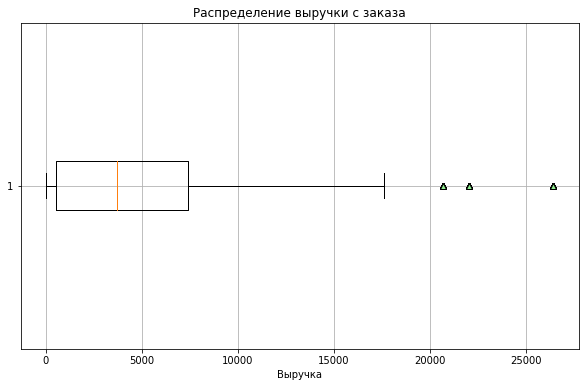

In [12]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    df['revenue'], 
    vert=False,
    flierprops=dict(markerfacecolor='lightgreen', marker='^')
)

plt.title('Распределение выручки с заказа')

plt.xlabel('Выручка')

plt.grid(True)

plt.show()

В данных с выручкой видим наличие выбросов. Отберем данные по 99-му процентилю:

In [13]:
#Разделим данные по валютам
df_rub = df[df['currency_code'] == 'rub']
df_kzt = df[df['currency_code'] == 'kzt']

#Вычислим 99-й процентиль для каждой валюты
percentile_rub = df_rub['revenue'].quantile(0.99)
percentile_kzt = df_kzt['revenue'].quantile(0.99)

#Отберем значения, которые больше или равны 99-му процентилю для каждой валюты
filtered_data_rub = df_rub[df_rub['revenue'] >= percentile_rub]
filtered_data_kzt = df_kzt[df_kzt['revenue'] >= percentile_kzt]


Проверим наличие выбросов в поле `tickets_count` с помощью диаграммы "ящик с усами"

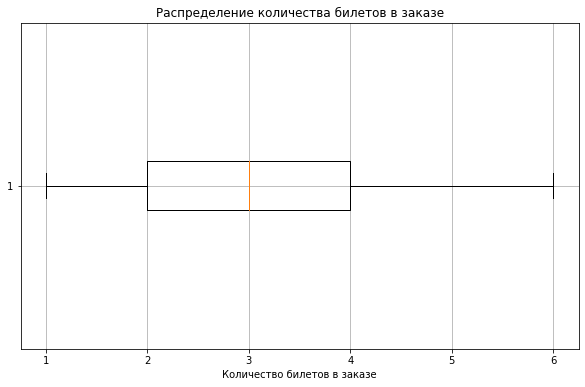

In [14]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    df['tickets_count'], 
    vert=False,
    flierprops=dict(markerfacecolor='lightgreen', marker='^')
)

plt.title('Распределение количества билетов в заказе')

plt.xlabel('Количество билетов в заказе')

plt.grid(True)

plt.show()

Исходя из диаграммы "ящик с усами" видим, что выбросов в значениях столбца `tickets_count` нет

Проверим наличие неявных дубликатов в столбце с информацией по бронированию билета. Проверим по столбцу `event_id`

In [15]:
df.duplicated(subset='event_id').sum()

1809548

Видим, что дубликатов практически столько же, сколько и данных в датафрейме (1809633). По определению идентификатор мероприятия должен быть уникальным, однако, проверим структуру данных:

In [16]:
df.groupby('event_type_main')['event_id'].count()

event_type_main
другое       548709
концерты    1147041
спорт        108885
стендап        1071
театр          3927
Name: event_id, dtype: int64

Видим, что на каждый тип мероприятия свой отдельный идентификатор, поэтому дублирование - не аномалия

Проверим наличие дубликатов в столбце с идентификатором пользователя:

In [17]:
df.duplicated(subset='user_id').sum()

1808273

Видим, что дубликатов очень много, выведем таблицу, чтобы понять, почему такое большое количество дублирований:

In [18]:
pd.set_option('display.max_columns', None)
duplicates = df[df.duplicated(subset='user_id', keep=False)] 
display(duplicates)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx
0,7850214,0033403583a55ed,2024-09-17,2024-09-17 16:52:06,559919,нет,6,kzt,mobile,518.10,Билеты без проблем,4,10361.97,20.0,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,событие,другое,№5088,Верхоречная область,Серебрянка,163,1533,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-01-10,100,19.9391,kzt
1,7850214,0033403583a55ed,2024-09-17,2024-09-17 16:52:06,559919,нет,6,kzt,mobile,518.10,Билеты без проблем,4,10361.97,20.0,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,событие,другое,№5088,Верхоречная область,Серебрянка,163,1533,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-01-11,100,19.7255,kzt
2,7850214,0033403583a55ed,2024-09-17,2024-09-17 16:52:06,559919,нет,6,kzt,mobile,518.10,Билеты без проблем,4,10361.97,20.0,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,событие,другое,№5088,Верхоречная область,Серебрянка,163,1533,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-01-12,100,19.5839,kzt
3,7850214,0033403583a55ed,2024-09-17,2024-09-17 16:52:06,559919,нет,6,kzt,mobile,518.10,Билеты без проблем,4,10361.97,20.0,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,событие,другое,№5088,Верхоречная область,Серебрянка,163,1533,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-01-13,100,19.4501,kzt
4,7850214,0033403583a55ed,2024-09-17,2024-09-17 16:52:06,559919,нет,6,kzt,mobile,518.10,Билеты без проблем,4,10361.97,20.0,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,событие,другое,№5088,Верхоречная область,Серебрянка,163,1533,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-01-14,100,19.4501,kzt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1809628,3093808,dfa6b4f4dd58d55,2024-10-31,2024-10-31 15:31:03,583623,нет,6,kzt,mobile,680.89,Билеты без проблем,3,13617.87,0.0,d76e86d7-4d41-46e5-9cd6-61d7e1459a85,событие,другое,№5088,Верхоречная область,Серебрянка,163,1533,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-12-27,100,19.2705,kzt
1809629,3093808,dfa6b4f4dd58d55,2024-10-31,2024-10-31 15:31:03,583623,нет,6,kzt,mobile,680.89,Билеты без проблем,3,13617.87,0.0,d76e86d7-4d41-46e5-9cd6-61d7e1459a85,событие,другое,№5088,Верхоречная область,Серебрянка,163,1533,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-12-28,100,19.5105,kzt
1809630,3093808,dfa6b4f4dd58d55,2024-10-31,2024-10-31 15:31:03,583623,нет,6,kzt,mobile,680.89,Билеты без проблем,3,13617.87,0.0,d76e86d7-4d41-46e5-9cd6-61d7e1459a85,событие,другое,№5088,Верхоречная область,Серебрянка,163,1533,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-12-29,100,19.4860,kzt
1809631,3093808,dfa6b4f4dd58d55,2024-10-31,2024-10-31 15:31:03,583623,нет,6,kzt,mobile,680.89,Билеты без проблем,3,13617.87,0.0,d76e86d7-4d41-46e5-9cd6-61d7e1459a85,событие,другое,№5088,Верхоречная область,Серебрянка,163,1533,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-12-30,100,19.4860,kzt


На примере выведенной таблицы видим, что данные полностью дублируют друг друга, за исключением столбца с курсом казахстанского тенге. Возможно, пользователи хотели купить билеты по наиболее выгодному курсу, так как создания новых заказов не происходит, исходя из столбца с идентификатором заказа, либо такие данные могли появиться из-за технической ошибки

Проверим наличие полных дубликатов в датафрейме:

In [19]:
#Проверим дубликаты без учёта столбца 'curs'
duplicates_curs = df.drop('curs', axis=1).duplicated()

duplicates_curs.sum()

0

In [20]:
#Проверим полные дубликаты в датафрейме
df.duplicated().sum()

0

Однако полных дупликатов в датафрейме нет

Считаю, что некорректно удалять такие данные из датафрейма, так как это львиная доля данных, поэтому данные оставим так, как есть

Проведем преобразования типов данных. Проверим размерность данных в датафрейме и снизим ее, если это возможно, для оптимизации памяти и ускорения вычислений

Проведем преобразование типов данных с понижением размерности:

In [21]:
#Меняем тип данных на целочисленный с понижением размерности данных
df['order_id'] = pd.to_numeric(df['order_id'], downcast='integer')
df['event_id'] = pd.to_numeric(df['event_id'], downcast='integer')
df['age_limit'] = pd.to_numeric(df['age_limit'], downcast='integer')
df['revenue'] = pd.to_numeric(df['revenue'], downcast='float')
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')
df['total'] = pd.to_numeric(df['total'], downcast='float')
df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], downcast='float')
df['city_id'] = pd.to_numeric(df['city_id'], downcast='integer')
df['venue_id'] = pd.to_numeric(df['venue_id'], downcast='integer')
df['nominal'] = pd.to_numeric(df['nominal'], downcast='integer')
df['curs'] = pd.to_numeric(df['curs'], downcast='float')
df['order_id'] = pd.to_numeric(df['order_id'], downcast='integer')

Размерность типа данных была уменьше в 2, 4 и 8 раз в столбцах с количественными данными

Создадим новый столбец `revenue_rub`, в котором приведем выручку с заказа к единой валюте — российскому рублю

In [22]:
df['revenue_rub'] = df['revenue'] * df['curs'] / df['nominal']

In [23]:
print(df['revenue_rub'])

0          103.304474
1          102.197815
2          101.464180
3          100.770966
4          100.770966
              ...    
1809628    131.210907
1809629    132.845047
1809630    132.678238
1809631    132.678238
1809632    132.678238
Name: revenue_rub, Length: 1809633, dtype: float32


Создадим новый столбец `one_ticket_revenue_rub`, где рассчитаем выручку с продажи одного билета на мероприятие

In [24]:
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

In [25]:
print(df['one_ticket_revenue_rub'])

0          25.826118
1          25.549454
2          25.366045
3          25.192741
4          25.192741
             ...    
1809628    43.736969
1809629    44.281681
1809630    44.226078
1809631    44.226078
1809632    44.226078
Name: one_ticket_revenue_rub, Length: 1809633, dtype: float32


Создадим новый столбец `month`, где выделим месяц оформления заказа

In [26]:
df['month'] = df['created_dt_msk'].dt.month

In [27]:
print(df['month'])

0           9
1           9
2           9
3           9
4           9
           ..
1809628    10
1809629    10
1809630    10
1809631    10
1809632    10
Name: month, Length: 1809633, dtype: int64


Создадим новый столбец `season` с информацией о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'

In [28]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'

df['season'] = df['month'].apply(get_season)

In [29]:
print(df['season'])

0          осень
1          осень
2          осень
3          осень
4          осень
           ...  
1809628    осень
1809629    осень
1809630    осень
1809631    осень
1809632    осень
Name: season, Length: 1809633, dtype: object


На этом этапе предобработка данных завершена, выделим ключевые шаги, которые были проделаны:
- для предобработки был создан один общий датафрейм на основании трех датафреймов `df`
- проверили содержание пропусков в столбцах датафрейма, пропуски были обнаружены только в столбце `days_since_prev`, что нормально, исходя из ТЗ
- привели столбцы с датой и временем к соответствующему типу данных, а также подобрали оптимальный размер числовых данных для оптимизации работы с данными
- изучили наличие выбросов в столбцах с выручкой и количеством билетов в заказе на основе диаграммы "ящик с усами". Было обнаружено небольшое количество выбросов в данных с выручкой, данные были отобраны по 99-му процентилю
- были выявлены неявные дупликаты в столбце с идентификатором клиента (1808273 шт.). Оказалось, что данные дублируются полностью, за исключением курса казахстанского тенге к рублю, предполагаем, что пользователи хотели приобрести билеты по более выгодному курсу, однако время заказа оставалось неизменным
    - был создан новый столбец `revenue_rub`, в котором отражена выручка в российских рублях
    - был создан новый столбец `one_ticket_revenue_rub`, где рассчитана выручка с одного билета на мероприятие
    - был создан новый столбец `month` с выделением месяца из даты
    - на основе столбца `month` был создан столбец `season`, который отражает сезонность совершенных заказов

## Исследовательский анализ данных

### Анализ распределения заказов по сегментам и их сезонные изменения

В этом разделе изучим распределение заказов по сегментам и их сезонные изменения. 
Проанализируем динамику по разрезам:
- тип мероприятия `event_type_main`
- тип устройства `device_type_canonical`
- категория мероприятий по возрастному рейтингу `age_limit`

Для каждого месяца найдем количество заказов и визуализируем результаты:

In [30]:
df.groupby('month')['order_id'].count()

month
6     853230
7      94248
8     251328
9     400554
10    210273
Name: order_id, dtype: int64

Видим, что пик заказов за весь анализируемый период пришелся на июнь (853230), после чего был спад в июле и небольшой рост в августе, осенью наблюдаем увеличение количества заказов, однако только в сентябре, в октябре динамика снижается

На основании полного летнего сезона и неполного осеннего сложно сказать, что именно осенью наблюдаем рост количества заказов, так как из-за наибольшего количества заказов в июне и в августе (что больше октября) - летний сезон лидирует над осенним

Визуализируем данные на столбчатой диаграмме:

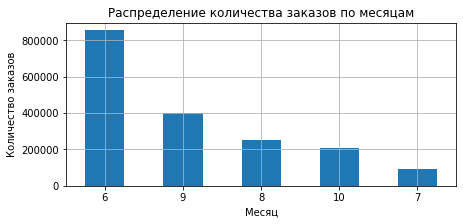

In [31]:
plt.figure(figsize=(7, 3))

df.groupby('month')['order_id'].count().sort_values(ascending=False).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=360, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение количества заказов по месяцам'
)

# Настраиваем оформление графика
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Для осеннего и летнего периодов сравним распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу:

In [32]:
df.groupby(['season', 'event_type_main', 'device_type_canonical', 'age_limit'])['order_id'].count()

season  event_type_main  device_type_canonical  age_limit
лето    другое           desktop                0               357
                                                6             11067
                                                16            26418
                         mobile                 0              4284
                                                6             64260
                                                16            59619
        концерты         desktop                12           186711
                                                16           166719
                                                18             1071
                         mobile                 6               714
                                                12           331296
                                                16           321300
                                                18             6426
        спорт            desktop                0         

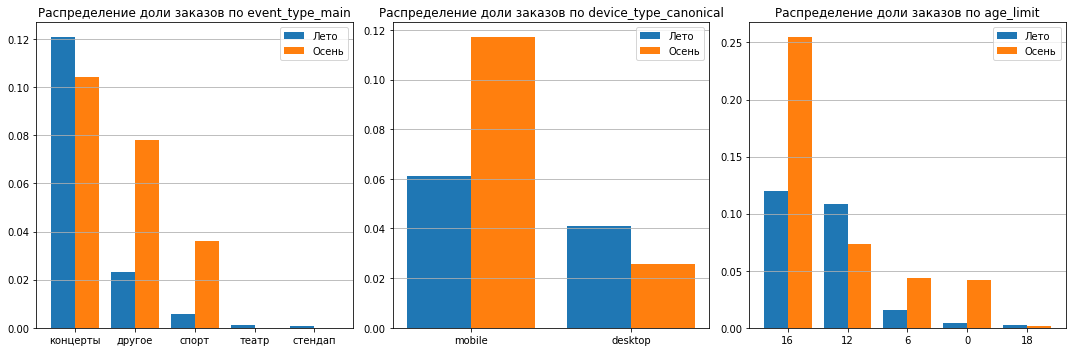

In [33]:
# Группируем данные по сезонам и категориям
grouped = df.groupby(['season', 'event_type_main', 'device_type_canonical', 'age_limit']).size().reset_index(name='count')

# Считаем доли заказов для каждой категории
grouped['share'] = grouped.groupby('season')['count'].apply(lambda x: x / x.sum())

# Визуализируем результаты
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

for i, category in enumerate(['event_type_main', 'device_type_canonical', 'age_limit']):
    summer_data = grouped[grouped['season'] == 'лето'].groupby(category)['share'].mean().sort_values(ascending=False)
    autumn_data = grouped[grouped['season'] == 'осень'].groupby(category)['share'].mean().sort_values(ascending=False)

    # Проверяем длины и выравниваем их
    len_summer = len(summer_data)
    len_autumn = len(autumn_data)
    if len_summer > len_autumn:
        autumn_data = pd.concat([autumn_data, pd.Series([0] * (len_summer - len_autumn))])
    elif len_autumn > len_summer:
        summer_data = pd.concat([summer_data, pd.Series([0] * (len_autumn - len_summer))])

    # Строим столбчатые диаграммы без накопления
    x = range(len(summer_data))
    axes[i].bar(x, summer_data, width=0.4, label='Лето')
    axes[i].bar([xi + 0.4 for xi in x], autumn_data, width=0.4, label='Осень')

    axes[i].set_title(f'Распределение доли заказов по {category}')
    axes[i].legend()
    axes[i].grid(axis='y')
    axes[i].set_xticks([xi + 0.2 for xi in x])  # Устанавливаем метки по центру столбцов
    axes[i].set_xticklabels(summer_data.index, rotation=0)

plt.tight_layout()
plt.show()

Сделаем вывод по трем построенным графикам:
- в разрезе по основному типу мероприятия видим, что в категории "другое" превалирует доля заказов летом, а в категории спорта и концертов, наборот, осенью. Видимо эти категории имеют более сезонный характер, ведь многие возвращаются из отпусков
- в разрезе типа устройства видим, что с мобильных телефонов чаще всего заказывают осенью, а летом, наоборот, со стационарных компьютеров
- в разрезе возрастной категории мероприятий видим, что осенью пользуются спросом категории `6+`, а летом `12+`

In [34]:
df.groupby(['season', 'event_type_main'])['one_ticket_revenue_rub'].mean()

season  event_type_main
лето    другое              76.892891
        концерты           562.099548
        спорт               84.575737
        стендап            289.256134
        театр               29.728989
осень   другое              32.794830
        концерты           443.410126
        спорт               68.574791
Name: one_ticket_revenue_rub, dtype: float32

Проанализируем сезонность мероприятий и выручку с них:

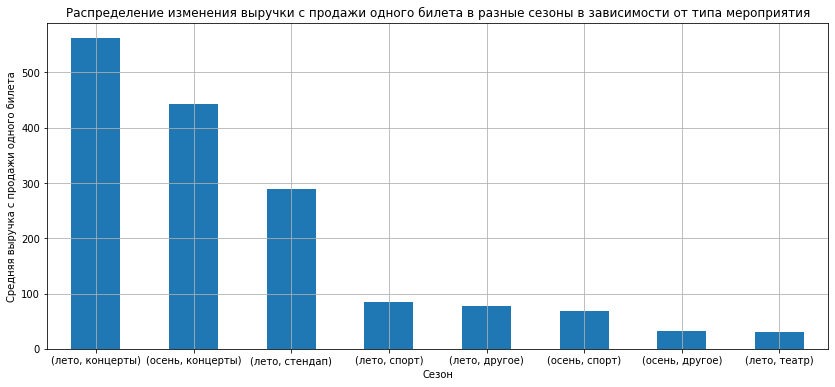

In [35]:
plt.figure(figsize=(14, 6))

df.groupby(['season', 'event_type_main'])['one_ticket_revenue_rub'].mean().sort_values(ascending=False).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=360, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение изменения выручки с продажи одного билета в разные сезоны в зависимости от типа мероприятия'
)

# Настраиваем оформление графика
plt.xlabel('Сезон')
plt.ylabel('Средняя выручка с продажи одного билета')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Видим, что летом наиболее высокая средняя выручка с продажи билетов на концерты, причем осенью лидируют также концерты, но с небольшим различием в средней выручке с одного билета около 100 рублей

Найдем относительное изменение осенних значений по сравнению с летними

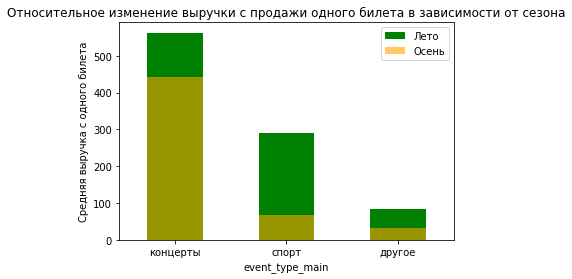

In [36]:
# Группируем данные по сезонам и категориям
grouped_type_main = df.groupby(['season', 'event_type_main'])['one_ticket_revenue_rub'].mean().reset_index()

# Разделяем данные для летнего и осеннего периодов
summer_type = grouped_type_main[grouped_type_main['season'] == 'лето']
autumn_type = grouped_type_main[grouped_type_main['season'] == 'осень']

# Рассчитываем относительное изменение
relative_change = (autumn_type['one_ticket_revenue_rub'] - summer_type['one_ticket_revenue_rub']) / summer_type['one_ticket_revenue_rub'] * 100

# Сортируем данные по убыванию
summer_type_sorted = summer_type.sort_values(by='one_ticket_revenue_rub', ascending=False)
autumn_type_sorted = autumn_type.sort_values(by='one_ticket_revenue_rub', ascending=False)

# Визуализация
fig, ax = plt.subplots()
summer_type_sorted.plot(kind='bar', x='event_type_main', y='one_ticket_revenue_rub', ax=ax, color='green', label='Лето', rot=0)
autumn_type_sorted.plot(kind='bar', x='event_type_main', y='one_ticket_revenue_rub', ax=ax, color='orange', label='Осень', alpha=0.6, rot=0)

ax.set_ylabel('Средняя выручка с одного билета')
ax.legend()
plt.title('Относительное изменение выручки с продажи одного билета в зависимости от сезона')
plt.show()


Видим, что относительное изменение средней выручки осенних значений по сравнению с летними ниже в категории концертов и сильно ниже в категориях спорта и другое

По проведенному анализу заключим: 
- с наступлением осени количество заказов имеет положительную динамику, однако их число все равно ниже, чем в первый месяц лета
- осенью растет популярность мероприятий в категории спорт (доля заказов относительно летнего периода), увеличивается число заказов с мобильного устройства и также имеет положительную динамику мероприятия с возрастным ограничением `6+`
- осенью также популярны и концерты, однако летом средняя выручка с одного билета все равно выше
- также и относительная выручка осеннего периода относительно летнего в категории концертов ниже, в категориях спорт и другое сильно ниже

Предполагаю, что мероприятия в категории спорт имеет меньшую стоимость билета, хотя осенью пользуются популярностью у пользователей сильно больше, чем концерты (видим по доле заказов относительно летнего периода). Концерты также востребованы осенью, но уже меньше, чем летом, ведь и число заказов, и выручка становятся меньше

### Осенняя активность пользователей

Изучим активность пользователей осенью 2024 года. Проанализируем динамику изменений по дням для:
- общего числа заказов;
- количества активных пользователей DAU;
- среднего числа заказов на одного пользователя;
- средней стоимости одного билета.

In [37]:
# Фильтруем данные за 9 и 10 месяцы
filtered_df = df[df['month'].isin([9, 10])]

# Группируем данные по дням
daily_summary = filtered_df.groupby('created_dt_msk').agg(
    total_orders=('order_id', 'count'),
    unique_users=('user_id', 'nunique')
).reset_index()

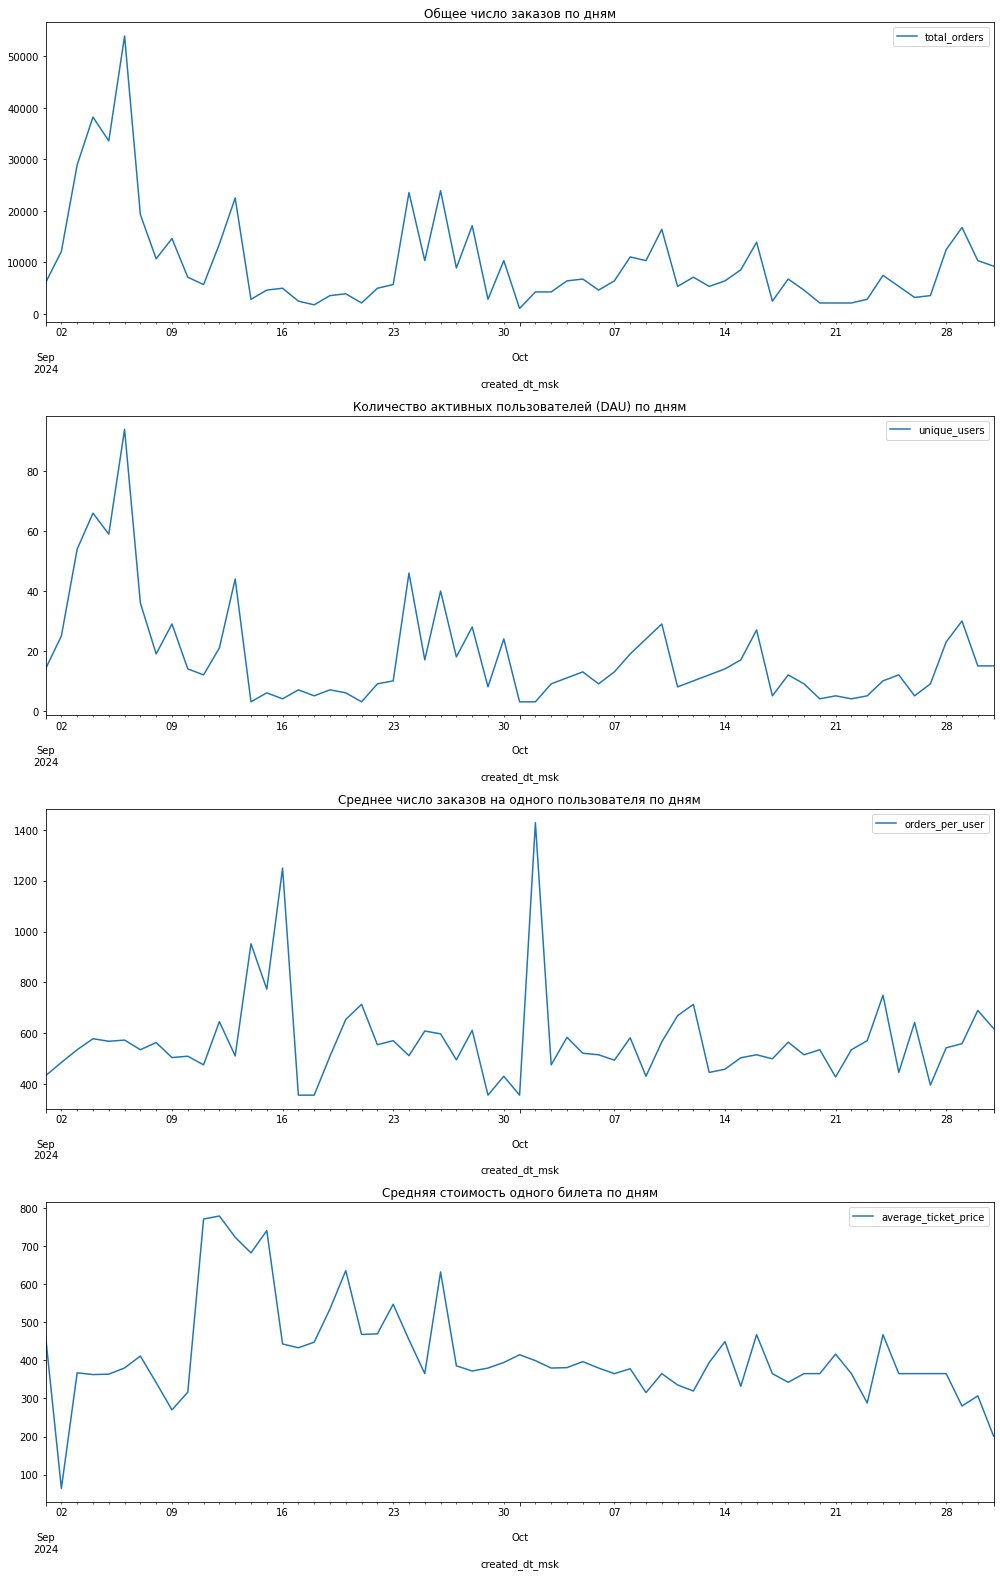

In [38]:
# Рассчитываем среднее число заказов на одного пользователя
daily_summary['orders_per_user'] = daily_summary['total_orders'] / daily_summary['unique_users']

# Рассчитываем среднюю стоимость одного билета
daily_summary['average_ticket_price'] = df.groupby('created_dt_msk')['one_ticket_revenue_rub'].mean().reset_index()['one_ticket_revenue_rub']

# Визуализация
fig, axs = plt.subplots(4, 1, figsize=(14, 22))

daily_summary.plot(x='created_dt_msk', y='total_orders', ax=axs[0], title='Общее число заказов по дням')
daily_summary.plot(x='created_dt_msk', y='unique_users', ax=axs[1], title='Количество активных пользователей (DAU) по дням')
daily_summary.plot(x='created_dt_msk', y='orders_per_user', ax=axs[2], title='Среднее число заказов на одного пользователя по дням')
daily_summary.plot(x='created_dt_msk', y='average_ticket_price', ax=axs[3], title='Средняя стоимость одного билета по дням')

plt.tight_layout()
plt.show()
 

- Изменение общего числа заказов и количество активных пользователей по осенним дням имеет положительную динамику на протяжении двух месяцев, однако в начале осени заметен пик заказов 6 числа. Возможно в этот день была размещена реклама или действовала промоакция, что привлекло наибольшее количество пользователей в сервис
- Динамика изменения среднего числа заказов на одного пользователя также положительна, однако пик приходится на начало месяца октября - 2 число, хотя на этот день приходится низкое изменение общего числа заказов
- Средняя стоимость одного билета положительна на всем периоде за исключением начала и конца месяца, нужно понять, что могло вызвать падение выручки в эти дни. Возможно, в эти дни на сервисе были предложены мероприятия с высоким ценником, что не нашло отклик у аудитории

Изучим недельную цикличность и сравним пользовательскую активность в будни и выходные:

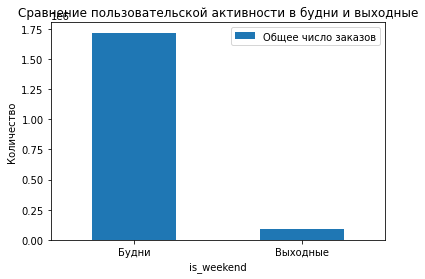

In [39]:
# Добавляем столбец с днём недели
df['day_of_week'] = df['created_dt_msk'].dt.dayofweek

# Разделяем дни на будни (0-5) и выходные (6-7)
df['is_weekend'] = df['day_of_week'].apply(lambda x: 'Выходные' if x >= 6 else 'Будни')

# Группируем данные и считаем количество заказов и уникальных пользователей
weekly_summary = df.groupby('is_weekend').agg(
    total_orders=('order_id', 'count'),
).reset_index()

# Визуализация
fig, ax = plt.subplots()
weekly_summary.plot(x='is_weekend', y='total_orders', kind='bar', ax=ax, label='Общее число заказов', rot=0)
ax.set_ylabel('Количество')
ax.legend()
plt.title('Сравнение пользовательской активности в будни и выходные')
plt.show()


Заметна значительная разница в количестве заказов между буднями и выходными: основная масса пользователей "готовится" к мероприятиям в будни и лишь небольшая часть приобретает билеты в выходные дни

Сформулируем промежуточный вывод о пользовательской активности и недельной цикличности:
- Общее число заказов имеет положительную динамику, пик заказов приходится на 6 число сентября. Необходимо понять, чем был вызван спрос, предположительно была запущена промоакция или действовала реклама
- Однако общее число заказов на одного пользователя имело пик в начале октября 2 числа. Возможно, было запущено персональное предложение? Так как на динамике числа заказов это не отразилось
- Средняя стоимость одного билета положительна на всем периоде, но виден спад в начале и в конце месяца. Предположительно в эти даты размещены самые дорогостоящие мероприятия
- При изучении недельной цикличности было выявлено, что число заказов сильно больше в будние дни относительно выходных

### Популярные события и партнёры

Проанализируем, как события распределены по регионам и партнёрам. Это позволит нам выделить ключевые регионы и партнёров, которые вносят наибольший вклад в выручку

In [41]:
df.groupby('region_name').agg({'event_id': 'nunique', 'order_id': 'count'}).sort_values(by='order_id', ascending=False)

,event_id,order_id
region_name,,
Шанырский регион,27,933198
Верхоречная область,56,852159
Каменевский регион,1,23919
Малиновая область,1,357


Из выведенной таблицы видим, что наибольшее количество мероприятий предлагается в `Верхоречной области`, однако наибольшее количество заказов приходится на `Шанырский район`

Для каждого региона посчитаем долю проводимых мероприятий от их общего числа

In [42]:
#Рассчитаем общее количество мероприятий для каждого региона
region_counts = df.groupby('region_name')['event_id'].nunique()

#Рассчитаем общее количество мероприятий во всех регионах
total_events = df['event_id'].nunique()

#Рассчитаем долю мероприятий для каждого региона от их общего числа
region_shares = (region_counts / total_events).sort_values(ascending=False)

print("Доля проводимых мероприятий по регионам:")
print(region_shares)

Доля проводимых мероприятий по регионам:
region_name
Верхоречная область    0.658824
Шанырский регион       0.317647
Каменевский регион     0.011765
Малиновая область      0.011765
Name: event_id, dtype: float64


Самая большая доля проводимых мероприятий выше в `Верхоречной области` и в `Шанырском регионе`

Для каждого региона рассчитаем долю заказов в регионе от общего числа заказов:

In [43]:
#Рассчитаем общее количество мероприятий для каждого региона
region_order = df.groupby('region_name')['order_id'].count()

#Рассчитаем общее количество мероприятий во всех регионах
total_order = df['order_id'].count()

#Рассчитаем долю мероприятий для каждого региона от их общего числа
region_shares_order = (region_order / total_order).sort_values(ascending=False)

print("Доля заказов по регионам:")
print(region_shares_order)

Доля заказов по регионам:
region_name
Шанырский регион       0.515684
Верхоречная область    0.470902
Каменевский регион     0.013218
Малиновая область      0.000197
Name: order_id, dtype: float64


По доле заказов лидирует `Шанырский регион`, затем `Верхоречная область` 

Для каждого билетного партнёра посчитайте общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов. Сделайте акцент на наиболее активных партнёрах.

In [44]:
df.groupby('service_name').agg({'event_id': 'nunique','order_id': 'count', 'revenue': 'sum'}).sort_values(by='revenue', ascending=False)

,event_id,order_id,revenue
service_name,,,
Мой билет,15,1173816,7.945926e+09
Билеты без проблем,51,590121,9.610191e+08
Цвет и билет,18,21777,9.178077e+07
Кино билет,1,23919,4.076550e+07


Наибольшую выручку приносит партнер `Мой билет`, у этого же партнера наибольшее количество заказов, однако по числу уникальных мероприятий партнер занимает третье место в рейтинге среди других. Наибольшее же количество мероприятий у партнера `Билеты без проблем`, выручка и количество заказов также наибольшие среди оставшихся после партнера `Мой билет`

Подводя итог, заметим, что среди общей массы регионов и билетных партнеров есть два лидера в одной и второй категориях. Так,
- Самая большая доля проводимых мероприятий в `Верхоречной области` и в `Шанырском регионе`
- По доле заказов, наоборот, лидирует `Шанырский регион` над `Верхоречной область` 
Что касается билетных партнеров, то наибольшую выручку сервису приносит партнер `Мой билет`, а наибольшее число мероприятий предлагает партнер `Билеты без проблем`

## Статистический анализ данных

Проверим две гипотезы, которые предполагают большую активность пользователей мобильных устройств:
- Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.
- Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

Перед проведением гипотезы посмотрим, как данные по заказам распределены между собой в разрезе устройств:

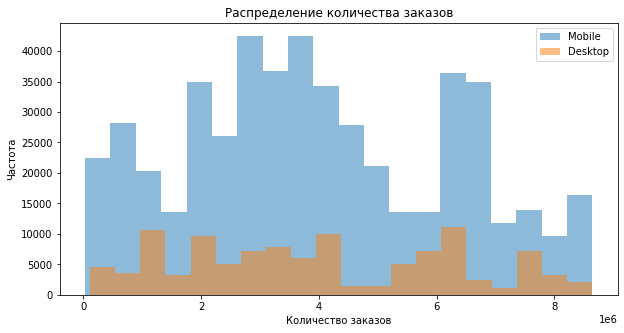

In [50]:
# Разделяем данные на две группы: мобильные и стационарные устройства
mobile_orders = filtered_df[filtered_df.device_type_canonical == 'mobile']['order_id']
desktop_orders = filtered_df[filtered_df.device_type_canonical == 'desktop']['order_id']

# Визуализация данных
plt.figure(figsize=(10, 5))
plt.hist(mobile_orders, bins=20, alpha=0.5, label='Mobile')
plt.hist(desktop_orders, bins=20, alpha=0.5, label='Desktop')
plt.legend()
plt.title('Распределение количества заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Частота')
plt.show()


Из графика видно, что частота использования мобильных устройств сильно выше частоты использования стационарных

Сформулируем нулевую и альтернативную гипотезы для предположения о том, что `среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств`

- Нулевая гипотеза: среднее количество заказов на одного пользователя мобильного приложения такое же, как и у пользователей стационарных устройств
- Альтернативная гипотеза: среднее количество заказов на одного пользователя мобильного приложения выше, чем у пользователей стационарных устройств 

Для анализа гипотезы выберем T-тест, потому что он позволяет сравнивать средние значения двух независимых выборок и определять, есть ли статистически значимое различие между ними:

In [ ]:
from scipy.stats import ttest_ind

# Рассчитываем среднее количество заказов для каждой группы
mean_mobile = mobile_orders.count() / filtered_df[filtered_df.device_type_canonical == 'mobile']['user_id'].nunique()
mean_desktop = desktop_orders.count() / filtered_df[filtered_df.device_type_canonical == 'desktop']['user_id'].nunique()

# Проводим t-тест для независимых выборок
alpha = 0.05  # уровень значимости
stat_ttest, p_value_ttest = ttest_ind(mobile_orders, desktop_orders, equal_var=False)

print(f'pvalue={p_value_ttest}')  # выводим полученное p-value

if p_value_ttest / 2 > alpha:  # учитываем односторонний тест
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

# Интерпретация результата
if p_value_ttest / 2 < alpha:
    text_interpretation = 'выше'
else:
    text_interpretation = 'не выше'

print(f'Среднее количество заказов на одного пользователя мобильного приложения {text_interpretation} по сравнению с пользователями стационарных устройств')


Из результатов теста видно, что среднее количество заказов на одного пользователя мобильного приложения такое же в сравнении с пользователями стационарных устройств

Рассмотрим второе предположение и сформулируем нулевую и альтернативную гипотезы о том, что `среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств`

- Нулевая гипотеза: среднее время между заказами пользователей мобильного приложения такое же, как и у пользователей стационарных устройств
- Альтернативная гипотеза: среднее время между заказами пользователей мобильного приложения выше, чем у пользователей стационарных устройств 

In [53]:
# Разделяем данные на две группы: мобильные и стационарные устройства
mobile_data = filtered_df[filtered_df.device_type_canonical == 'mobile']
desktop_data = filtered_df[filtered_df.device_type_canonical == 'desktop']

# Группируем данные по user_id и вычисляем время между заказами
mobile_grouped = mobile_data.groupby('user_id')['created_dt_msk'].apply(lambda x: x.diff().dt.total_seconds())
desktop_grouped = desktop_data.groupby('user_id')['created_dt_msk'].apply(lambda x: x.diff().dt.total_seconds())

# Рассчитываем среднее время между заказами для каждой группы
mean_mobile_time = mobile_grouped.mean()
mean_desktop_time = desktop_grouped.mean()

# Проводим t-тест для независимых выборок
alpha = 0.05  # уровень значимости
stat_ttest, p_value_ttest = ttest_ind(mobile_grouped.dropna(), desktop_grouped.dropna(), equal_var=False)

print(f'pvalue={p_value_ttest}')  # выводим полученное p-value

if p_value_ttest / 2 > alpha:  # учитываем односторонний тест
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

# Интерпретация результата
if p_value_ttest / 2 < alpha:
    text_interpretation = 'выше'
else:
    text_interpretation = 'не выше'

print(f'Среднее время между заказами пользователей мобильных приложений {text_interpretation} по сравнению с пользователями стационарных устройств')


pvalue=0.2254692570812923
Нулевая гипотеза находит подтверждение!
Среднее время между заказами пользователей мобильных приложений не выше по сравнению с пользователями стационарных устройств


Из результатов теста видно, что среднее время между заказами пользователей мобильных устройств такое же в сравнении с пользователями стационарных устройств

## Общий вывод и рекомендации

Резюмируя проведенный анализ данных:
- Для анализа были предоставлены полные данные, дубликатов и полных дубликатов в данных нет, но было обнаружено, что для одних и тех же данных (идентификатор заказа, пользователя и т.д.) в нескольких строках дублируются данные из-за разного курса казахстанского тенге. Предполагаю, что это или технический сбой, или попытка пользователем купить билеты по более выгодному курсу
- В данных также были обнаружены выбросы в столбце с выручкой
- Была подобрана оптимальная размерность типа данных в датафрейме

Основные результаты анализа:
- Из мероприятий наиболее востребованы `другое` и `спорт`. Причем популярность спортивных мероприятий выше осенью, а из категории другое - летом
- Осенью пользуются популярностью концерты и спортивные мероприятия, однако выручка за них ниже, чем в летний сезон
- Стоимость среднего чека менялась в зависимости от сезона: в летний период она была выше, чем в осенний
- При изучении пользовательской активности в осенний период было выявлено, что изменение общего числа заказов и количество активных пользователей имеет пик заказов 6 сентября. В динамике изменения среднего числа заказов на одного пользователя заметен пик 2 октября, однако общее число заказов в этот день невысокое
- При изучении регионов и партнеров были выделены лидеры: по числу заказов - `Шанырский регион`, а по выручке сервис `Мой билет`

Был проведен статистический анализ двух выдвинутых гипотез об изменении среднего количества заказов и среднего времени между заказами. Ни первая, ни вторая гипотеза не были подтверждены с предположениями о том, что на одного пользователя мобильного приложения приходится статистика выше по сравнению с пользователями стационарных устройств. Однако при предварительном знакомстве и анализе данных было видно явное превосходство мобильных устройств над стационарными

Рекомендации:
- Проанализировать наличие промоакций/реклам/личных предложений пользователям 6 сентября и 2 октября, так как именно на эти даты приходится наибольшее количество заказов и наибольшее изменение среднего числа заказов на одного пользователя, стоит внедрить эти `практики` в работу для увеличения динамики заказов
- Видимо, `не количество`, а `качество` мероприятий влияет на увеличение числа заказов. Стоит обратить внимание на мероприятия из категорий `концерты`, `спорт` и `другое` и возможно разнообразить их наполнение также для увеличения динамики
- Также стоит сделать упор на `Шанырский регион` и сервис `Мой билет`, т. к. именно в этом регионе наибольшее количество заказов, а этот сервис приносит наибольшую выручку. Стоит или перенять лучшие практики с этих бенчмарков на другие регионы и партнеров, либо продолжить развитие конкретного региона и сервиса